<a href="https://colab.research.google.com/github/sumaiyaSultanaTarin/Leukocyte-and-AML-segmentation/blob/main/aml_phase_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/AML_segmentation_project"

CHECKPOINT_DIR_AML = os.path.join(PROJECT_DIR, "checkpoints_aml")
LOG_DIR_AML = os.path.join(PROJECT_DIR, "logs_aml")

for d in [CHECKPOINT_DIR_AML, LOG_DIR_AML]:
    os.makedirs(d, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("AML checkpoint dir:", CHECKPOINT_DIR_AML)
print("AML log dir:", LOG_DIR_AML)

print("")
print("Contents of PROJECT_DIR:")
for item in sorted(os.listdir(PROJECT_DIR)):
    print(" ", item)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/AML_segmentation_project
AML checkpoint dir: /content/drive/MyDrive/AML_segmentation_project/checkpoints_aml
AML log dir: /content/drive/MyDrive/AML_segmentation_project/logs_aml

Contents of PROJECT_DIR:
  checkpoints
  checkpoints_aml
  data
  figures
  gold_subset
  logs
  logs_aml


In [ ]:
dataset_root = "/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU"
print("Contents of dataset_root:")
for item in sorted(os.listdir(dataset_root)):
    print(" ", item)


Contents of dataset_root:
  AML-Cytomorphology.sums
  BAS
  EBO
  EOS
  KSC
  LYA
  LYT
  MMZ
  MOB
  MON
  MYB
  MYO
  NGB
  NGS
  PMB
  PMO


In [ ]:
sample_class = "BAS"
sample_class_dir = os.path.join(dataset_root, sample_class)

files = sorted(os.listdir(sample_class_dir))
print("Number of files in", sample_class, ":", len(files))
print("First few files:")
for f in files[:10]:
    print(" ", f)


Number of files in BAS : 79
First few files:
  BAS_0001.tiff
  BAS_0002.tiff
  BAS_0003.tiff
  BAS_0004.tiff
  BAS_0005.tiff
  BAS_0006.tiff
  BAS_0007.tiff
  BAS_0008.tiff
  BAS_0009.tiff
  BAS_0010.tiff


In [ ]:
aml_classes = sorted([
    d for d in os.listdir(dataset_root)
    if os.path.isdir(os.path.join(dataset_root, d))
])
print("classes found:", aml_classes)


classes found: ['BAS', 'EBO', 'EOS', 'KSC', 'LYA', 'LYT', 'MMZ', 'MOB', 'MON', 'MYB', 'MYO', 'NGB', 'NGS', 'PMB', 'PMO']


In [ ]:
import pandas as pd

rows = []
for class_name in aml_classes:
    class_dir = os.path.join(dataset_root, class_name)
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(".tiff") or fname.lower().endswith(".tif"):
            rows.append({"class": class_name, "file_name": fname,
                         "path": os.path.join(class_dir, fname)})

aml_df = pd.DataFrame(rows)
print("")
print("total images:", len(aml_df))
print("")
print("per-class counts:")
print(aml_df["class"].value_counts())




total images: 18250

per-class counts:
class
NGS    8484
LYT    3937
MYO    3268
MON    1789
EOS     309
NGB     109
BAS      79
EBO      78
PMO      70
MYB      42
MOB      26
PMB      18
KSC      15
MMZ      15
LYA      11
Name: count, dtype: int64


In [ ]:
from PIL import Image
import numpy as np

sample_path = aml_df.loc[0, "path"]
sample_image = Image.open(sample_path)
sample_array = np.array(sample_image)

print("sample path:", sample_path)
print("PIL mode:", sample_image.mode)
print("image size (PIL, W x H):", sample_image.size)
print("array shape:", sample_array.shape)
print("array dtype:", sample_array.dtype)
print("min/max pixel values:", sample_array.min(), sample_array.max())



sample path: /content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/BAS/BAS_0002.tiff
PIL mode: RGBA
image size (PIL, W x H): (400, 400)
array shape: (400, 400, 4)
array dtype: uint8
min/max pixel values: 0 255


alpha channel unique values: [  0 255]


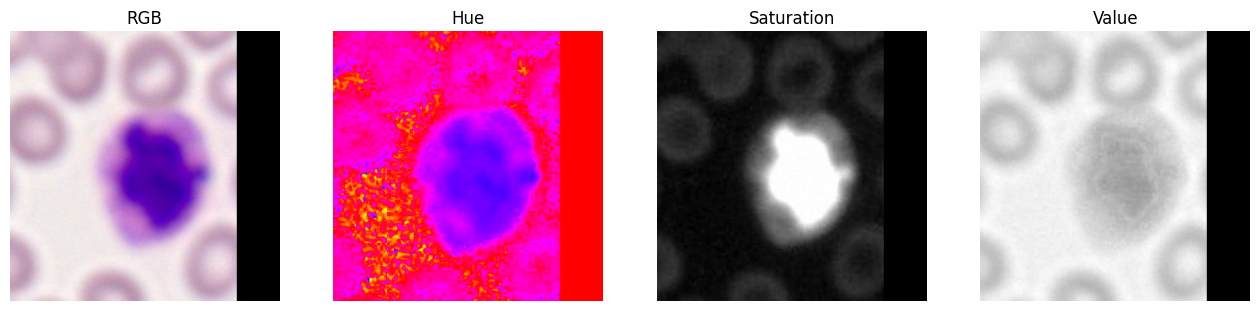

In [ ]:
import matplotlib.pyplot as plt
import colorsys

print("alpha channel unique values:", np.unique(sample_array[:, :, 3]))

rgb_array = sample_array[:, :, :3]
hsv_image = np.array(Image.fromarray(rgb_array).convert("HSV"))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(rgb_array)
axes[0].set_title("RGB")
axes[1].imshow(hsv_image[:, :, 0], cmap="hsv")
axes[1].set_title("Hue")
axes[2].imshow(hsv_image[:, :, 1], cmap="gray")
axes[2].set_title("Saturation")
axes[3].imshow(hsv_image[:, :, 2], cmap="gray")
axes[3].set_title("Value")
for ax in axes:
    ax.axis("off")
plt.show()


Otsu thresholds on saturation: [ 71.22070312 179.79492188]


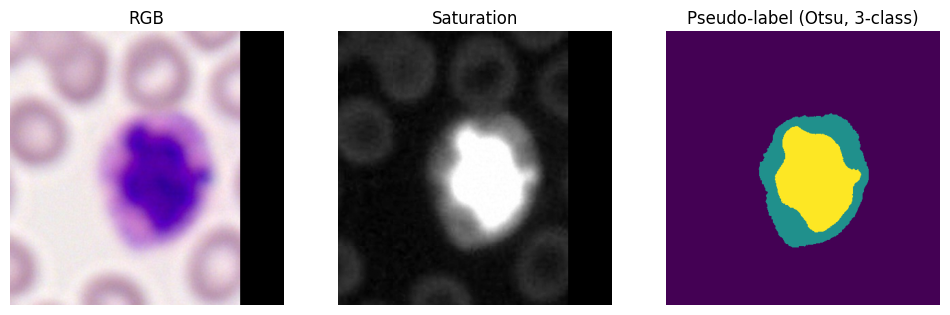

class 0 (background) pixel count: 136397
class 1 pixel count: 11126
class 2 pixel count: 12477


In [ ]:
from skimage.filters import threshold_multiotsu

alpha_mask = sample_array[:, :, 3] > 0
saturation = hsv_image[:, :, 1].astype(float)

thresholds = threshold_multiotsu(saturation[alpha_mask], classes=3)
print("Otsu thresholds on saturation:", thresholds)

pseudo_label = np.digitize(saturation, bins=thresholds)
pseudo_label[~alpha_mask] = 0  # force padding to background

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(rgb_array)
axes[0].set_title("RGB")
axes[1].imshow(saturation, cmap="gray")
axes[1].set_title("Saturation")
axes[2].imshow(pseudo_label, vmin=0, vmax=2)
axes[2].set_title("Pseudo-label (Otsu, 3-class)")
for ax in axes:
    ax.axis("off")
plt.show()

print("class 0 (background) pixel count:", (pseudo_label == 0).sum())
print("class 1 pixel count:", (pseudo_label == 1).sum())
print("class 2 pixel count:", (pseudo_label == 2).sum())


In [ ]:
from scipy import ndimage


In [ ]:
def generate_pseudo_label(image_array, opening_iterations=15):
    alpha_mask = image_array[:, :, 3] > 0
    rgb = image_array[:, :, :3]
    hsv = np.array(Image.fromarray(rgb).convert("HSV"))
    saturation = hsv[:, :, 1].astype(float)

    thresholds = threshold_multiotsu(saturation[alpha_mask], classes=3)
    label = np.digitize(saturation, bins=thresholds)
    label[~alpha_mask] = 0

    foreground = label > 0
    opened = ndimage.binary_opening(foreground, iterations=opening_iterations)

    components, n_components = ndimage.label(opened)
    center_y, center_x = label.shape[0] // 2, label.shape[1] // 2
    center_component = components[center_y, center_x]

    if center_component == 0:
        opened_ys, opened_xs = np.nonzero(opened)
        if len(opened_ys) == 0:
            label[:] = 0
            return label, rgb
        distances = (opened_ys - center_y) ** 2 + (opened_xs - center_x) ** 2
        nearest = np.argmin(distances)
        center_component = components[opened_ys[nearest], opened_xs[nearest]]

    core_mask = components == center_component
    label[foreground & ~core_mask] = 0
    return label, rgb


In [ ]:
check_classes = ["BAS", "LYT", "MYO", "MON", "NGS", "MOB"]


(image_array, opening_iterations=15)


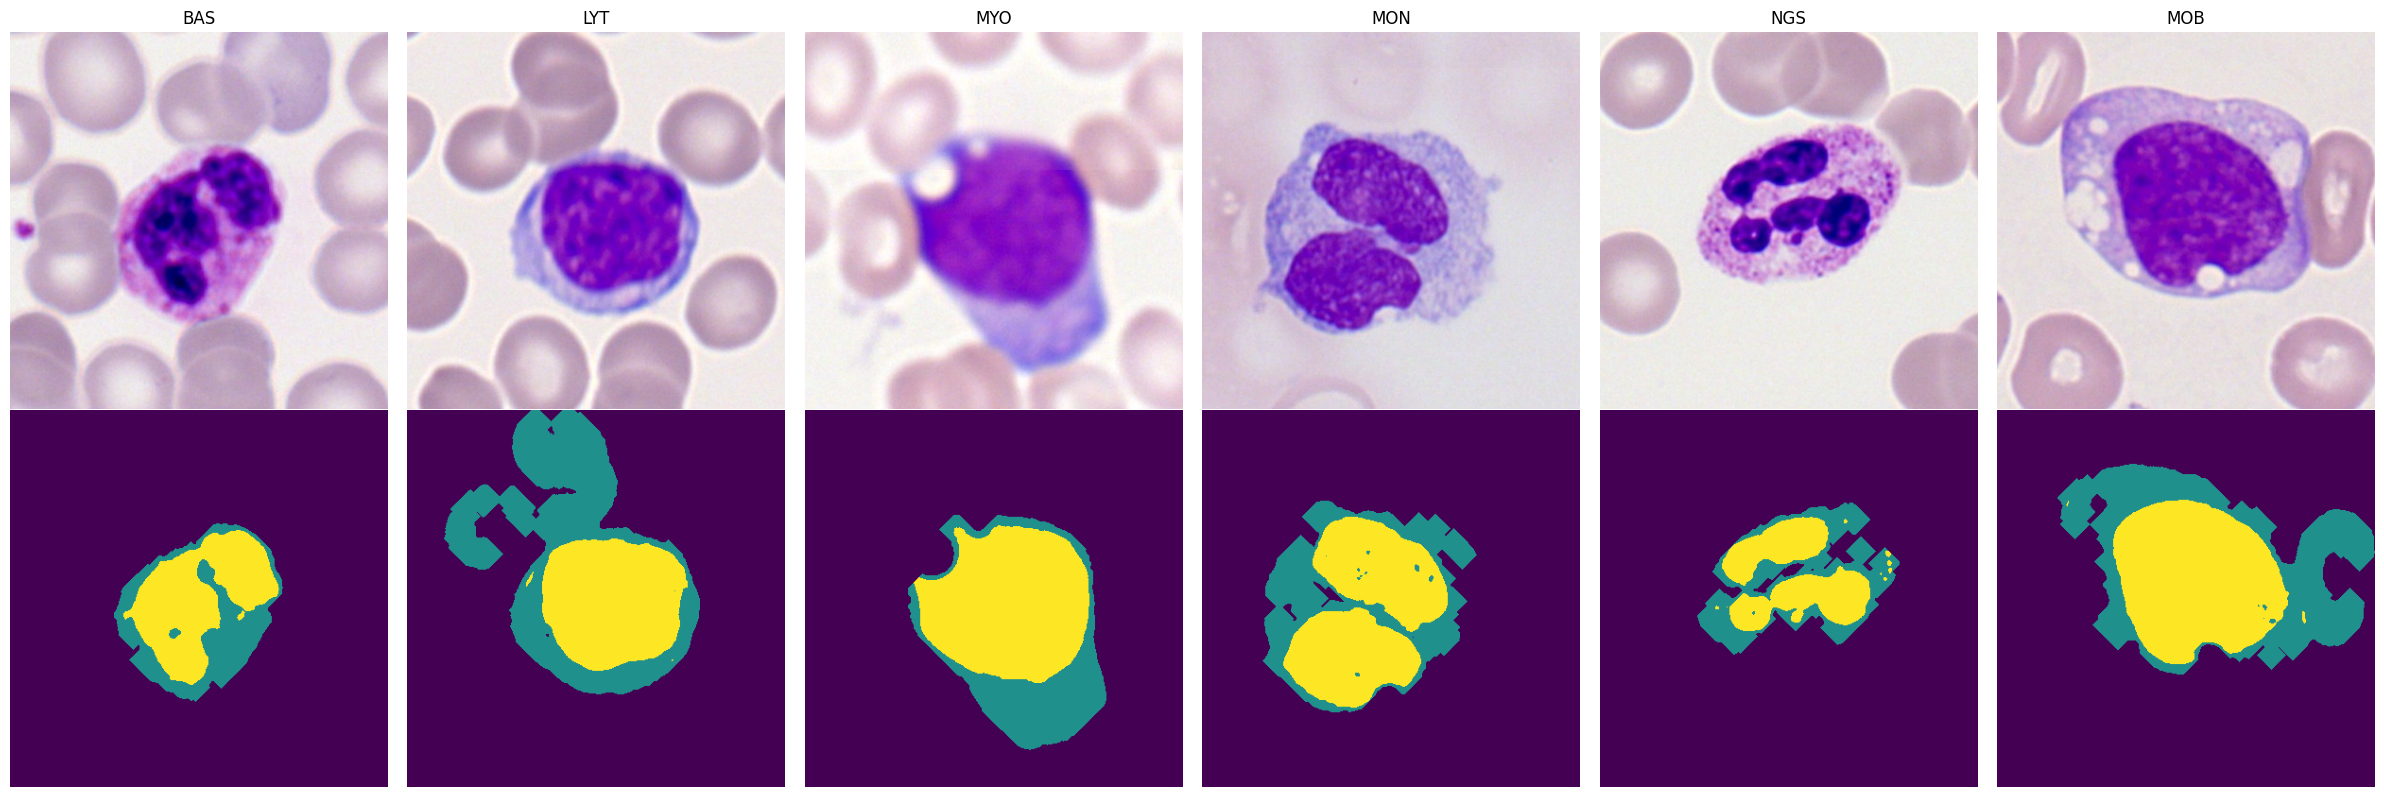

In [ ]:
import inspect
print(inspect.signature(generate_pseudo_label))

fig, axes = plt.subplots(2, len(check_classes), figsize=(4 * len(check_classes), 8))
for i, class_name in enumerate(check_classes):
    class_dir = os.path.join(dataset_root, class_name)
    fname = sorted(os.listdir(class_dir))[0]
    img_array = np.array(Image.open(os.path.join(class_dir, fname)))

    label, rgb = generate_pseudo_label(img_array)

    axes[0, i].imshow(rgb)
    axes[0, i].set_title(class_name)
    axes[0, i].axis("off")
    axes[1, i].imshow(label, vmin=0, vmax=2)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


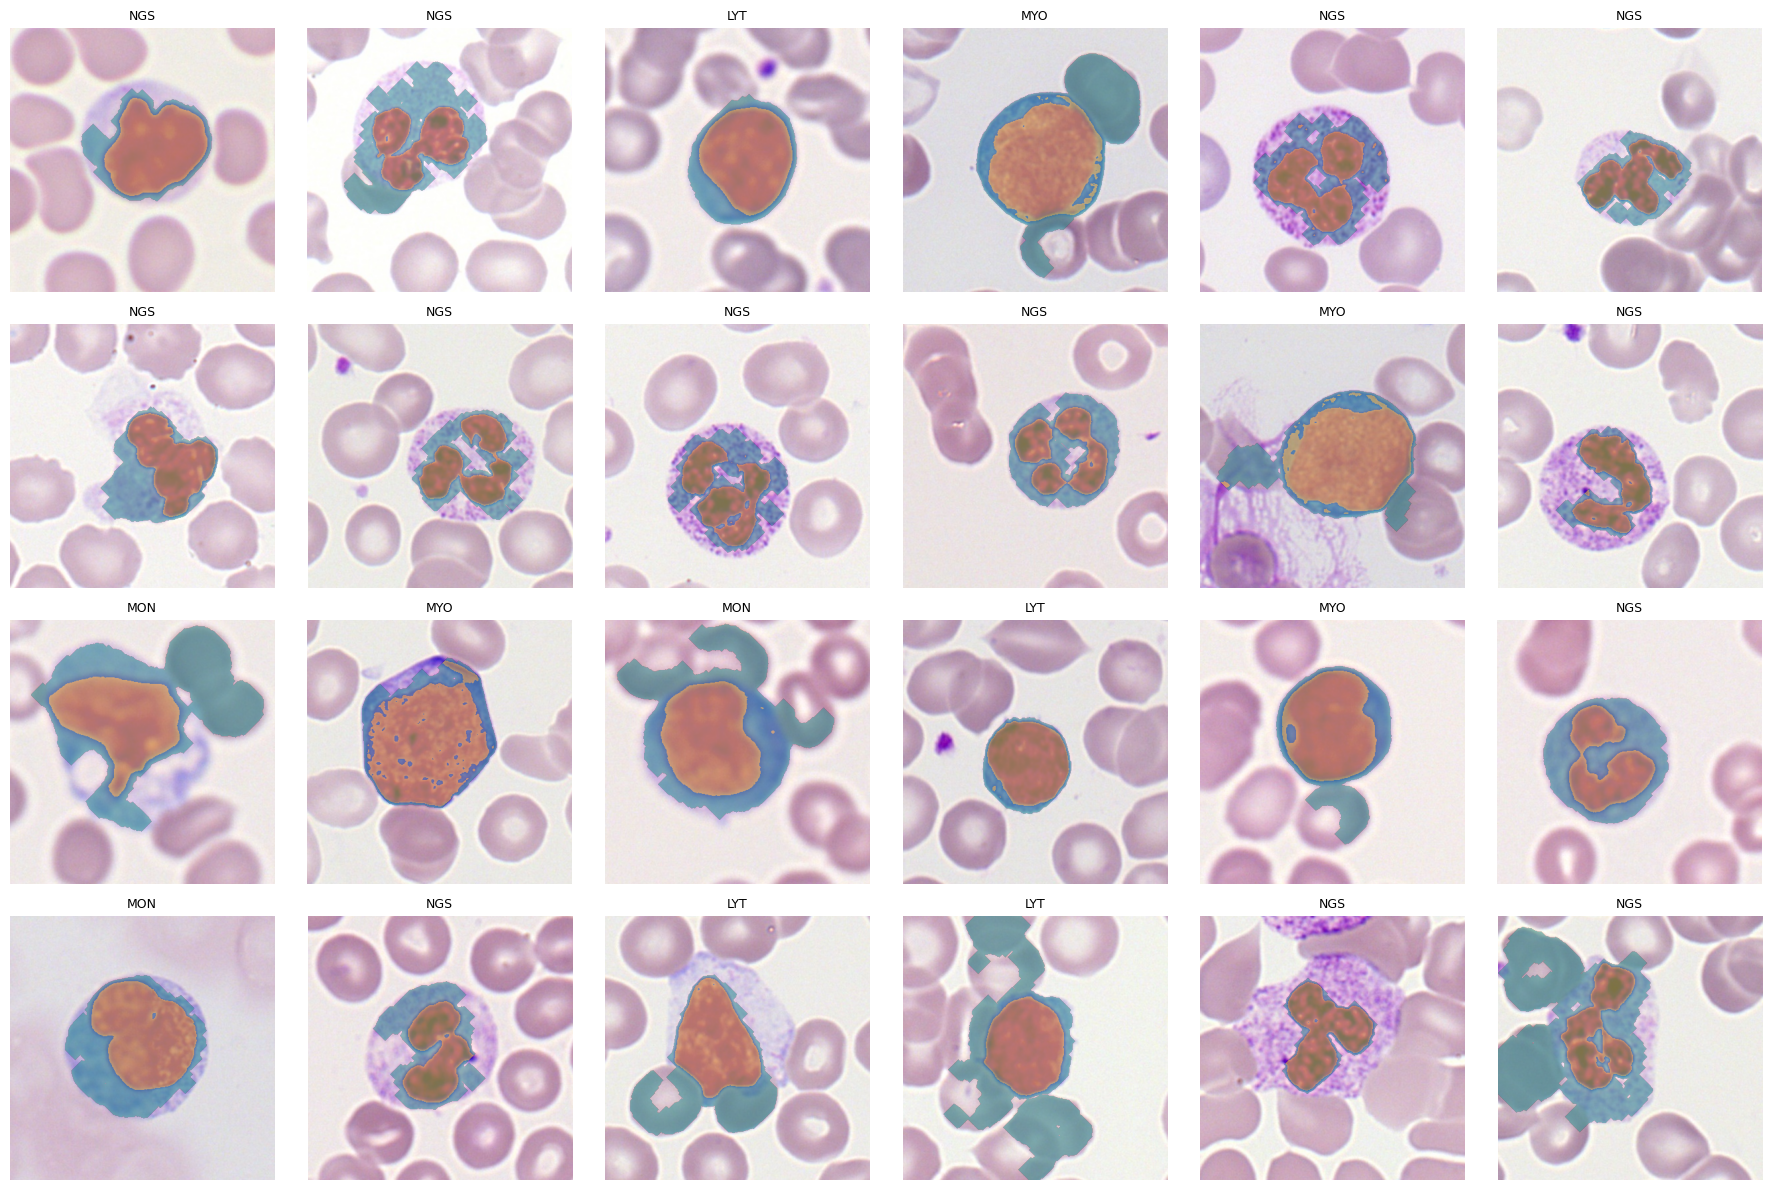

In [ ]:
import random as pyrandom

pyrandom.seed(0)
sample_indices = pyrandom.sample(range(len(aml_df)), 24)

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    row = aml_df.loc[idx]
    img_array = np.array(Image.open(row["path"]))
    label, rgb = generate_pseudo_label(img_array)

    ax.imshow(rgb)
    overlay = np.ma.masked_where(label == 0, label)
    ax.imshow(overlay, alpha=0.5, vmin=0, vmax=2)
    ax.set_title(row["class"], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
GOLD_DIR = os.path.join(PROJECT_DIR, "gold_subset")
REVIEW_DIR = os.path.join(GOLD_DIR, "to_review")
GOLD_MASKS_DIR = os.path.join(GOLD_DIR, "gold_masks")
os.makedirs(REVIEW_DIR, exist_ok=True)
os.makedirs(GOLD_MASKS_DIR, exist_ok=True)

actual_files = sorted(os.listdir(REVIEW_DIR))
print("actual files in to_review folder:", len(actual_files))

rebuilt_rows = []
for fname in actual_files:
    if not fname.endswith("_review.png"):
        continue
    stem = fname.replace("_review.png", "")
    class_name = stem.split("_")[0]
    tiff_stem = stem[len(class_name) + 1:]
    tiff_name = tiff_stem + ".tiff"
    match = aml_df[(aml_df["class"] == class_name) & (aml_df["file_name"] == tiff_name)]
    if len(match) == 0:
        print("could not match back to aml_df:", fname)
        continue
    rebuilt_rows.append(match.iloc[0])

gold_candidates_df = pd.DataFrame(rebuilt_rows).reset_index(drop=True)
gold_candidates_df["expected_filename"] = gold_candidates_df.apply(
    lambda row: row["class"] + "_" + row["file_name"].replace(".tiff", "") + "_review.png",
    axis=1
)

print("rebuilt gold_candidates_df size:", len(gold_candidates_df))



actual files in to_review folder: 50
rebuilt gold_candidates_df size: 50


In [ ]:
final_list = gold_candidates_df[["class", "file_name"]].to_dict(orient="records")
for row in final_list:
    print(f'    {{"class": "{row["class"]}", "file_name": "{row["file_name"]}"}},')


    {"class": "BAS", "file_name": "BAS_0046.tiff"},
    {"class": "BAS", "file_name": "BAS_0062.tiff"},
    {"class": "EBO", "file_name": "EBO_0024.tiff"},
    {"class": "EBO", "file_name": "EBO_0051.tiff"},
    {"class": "EOS", "file_name": "EOS_0169.tiff"},
    {"class": "EOS", "file_name": "EOS_0353.tiff"},
    {"class": "KSC", "file_name": "KSC_0002.tiff"},
    {"class": "KSC", "file_name": "KSC_0008.tiff"},
    {"class": "LYA", "file_name": "LYA_0004.tiff"},
    {"class": "LYA", "file_name": "LYA_0006.tiff"},
    {"class": "LYT", "file_name": "LYT_0452.tiff"},
    {"class": "LYT", "file_name": "LYT_0915.tiff"},
    {"class": "LYT", "file_name": "LYT_1863.tiff"},
    {"class": "LYT", "file_name": "LYT_2047.tiff"},
    {"class": "LYT", "file_name": "LYT_2726.tiff"},
    {"class": "LYT", "file_name": "LYT_3824.tiff"},
    {"class": "MMZ", "file_name": "MMZ_0007.tiff"},
    {"class": "MMZ", "file_name": "MMZ_0011.tiff"},
    {"class": "MOB", "file_name": "MOB_0014.tiff"},
    {"class"

In [ ]:
BLAST_CLASSES = ["MYO", "MOB", "PMO", "PMB", "MYB", "MMZ"]

gold_used = set(zip(gold_candidates_df["class"], gold_candidates_df["file_name"]))

aml_pool_df = aml_df[
    ~aml_df.apply(lambda row: (row["class"], row["file_name"]) in gold_used, axis=1)
].reset_index(drop=True)

print("pool size after excluding gold images:", len(aml_pool_df), "out of", len(aml_df))

pyrandom.seed(3)

subset_rows = []
for class_name in aml_classes:
    target = 45 if class_name in BLAST_CLASSES else 20
    class_pool = aml_pool_df[aml_pool_df["class"] == class_name]
    n_available = len(class_pool)
    sample_n = min(target, n_available)
    sampled = class_pool.sample(n=sample_n, random_state=3)
    subset_rows.append(sampled)
    print(f"  {class_name}: {sample_n} / target {target} (pool had {n_available})")

phase2_subset_df = pd.concat(subset_rows).reset_index(drop=True)
print("")
print("Phase II training subset total:", len(phase2_subset_df))


pool size after excluding gold images: 18200 out of 18250
  BAS: 20 / target 20 (pool had 77)
  EBO: 20 / target 20 (pool had 76)
  EOS: 20 / target 20 (pool had 307)
  KSC: 13 / target 20 (pool had 13)
  LYA: 9 / target 20 (pool had 9)
  LYT: 20 / target 20 (pool had 3931)
  MMZ: 13 / target 45 (pool had 13)
  MOB: 24 / target 45 (pool had 24)
  MON: 20 / target 20 (pool had 1785)
  MYB: 40 / target 45 (pool had 40)
  MYO: 45 / target 45 (pool had 3262)
  NGB: 20 / target 20 (pool had 107)
  NGS: 20 / target 20 (pool had 8472)
  PMB: 16 / target 45 (pool had 16)
  PMO: 45 / target 45 (pool had 68)

Phase II training subset total: 345


AML Dataset class and transforms

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

In [ ]:
AML_IMAGENET_MEAN = (0.485, 0.456, 0.406)
AML_IMAGENET_STD = (0.229, 0.224, 0.225)

aml_basic_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=AML_IMAGENET_MEAN, std=AML_IMAGENET_STD),
    ToTensorV2(),
])

aml_train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0, p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), p=0.5),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.5),
    A.Normalize(mean=AML_IMAGENET_MEAN, std=AML_IMAGENET_STD),
    ToTensorV2(),
])


class AMLDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img_array = np.array(Image.open(row["path"]))
        label, rgb = generate_pseudo_label(img_array)

        transformed = self.transform(image=rgb, mask=label)
        image_tensor = transformed["image"]
        mask_tensor = transformed["mask"].long()

        return image_tensor, mask_tensor


sanity_dataset = AMLDataset(phase2_subset_df, aml_basic_transform)
img, msk = sanity_dataset[0]
print("image tensor shape:", img.shape, img.dtype)
print("mask tensor shape:", msk.shape, msk.dtype)
print("mask unique values:", torch.unique(msk))


image tensor shape: torch.Size([3, 256, 256]) torch.float32
mask tensor shape: torch.Size([256, 256]) torch.int64
mask unique values: tensor([0, 1, 2])


In [ ]:
def stratified_split(df, train_frac=0.7, val_frac=0.15, seed=42):
    train_parts, val_parts, test_parts = [], [], []
    for class_name in sorted(df["class"].unique()):
        class_df = df[df["class"] == class_name].sample(frac=1, random_state=seed).reset_index(drop=True)
        n = len(class_df)
        n_train = max(1, round(n * train_frac))
        n_train = min(n_train, n)
        n_val = max(1, round(n * val_frac)) if n - n_train >= 2 else 0
        n_val = min(n_val, n - n_train)
        train_parts.append(class_df.iloc[:n_train])
        val_parts.append(class_df.iloc[n_train:n_train + n_val])
        test_parts.append(class_df.iloc[n_train + n_val:])

    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)
    return train_df, val_df, test_df


aml_train_df, aml_val_df, aml_test_df = stratified_split(phase2_subset_df)

print("train:", len(aml_train_df), "val:", len(aml_val_df), "test:", len(aml_test_df))
print("")
print("per-class train counts:")
print(aml_train_df["class"].value_counts())


train: 240 val: 52 test: 53

per-class train counts:
class
MYO    31
PMO    31
MYB    28
MOB    17
BAS    14
EBO    14
EOS    14
MON    14
NGB    14
NGS    14
LYT    14
PMB    11
KSC     9
MMZ     9
LYA     6
Name: count, dtype: int64


In [ ]:
BATCH_SIZE_AML = 16

aml_train_dataset = AMLDataset(aml_train_df, aml_train_transform)
aml_val_dataset = AMLDataset(aml_val_df, aml_basic_transform)
aml_test_dataset = AMLDataset(aml_test_df, aml_basic_transform)

aml_train_loader = DataLoader(
    aml_train_dataset,
    batch_size=BATCH_SIZE_AML,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False,
)

aml_val_loader = DataLoader(
    aml_val_dataset,
    batch_size=BATCH_SIZE_AML,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False,
)

aml_test_loader = DataLoader(
    aml_test_dataset,
    batch_size=BATCH_SIZE_AML,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False,
)

print("train batches per epoch:", len(aml_train_loader))
print("val batches per epoch:", len(aml_val_loader))
print("test batches per epoch:", len(aml_test_loader))

images, masks = next(iter(aml_train_loader))
print("batch image shape:", images.shape)
print("batch mask shape:", masks.shape)


train batches per epoch: 15
val batches per epoch: 4
test batches per epoch: 4
batch image shape: torch.Size([16, 3, 256, 256])
batch mask shape: torch.Size([16, 256, 256])


model and losses (reused from Phase I)

In [ ]:
!pip install -q segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.3 MB/s eta 0:00:00


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp
from torch.amp import autocast, GradScaler


class RatioFeedbackGate(nn.Module):
    def __init__(self, channels, hidden=8, epsilon=1e-6, init_bias=-4.0):
        super().__init__()
        self.epsilon = epsilon
        self.probe_head = nn.Conv2d(channels, 3, kernel_size=1)
        self.fc1 = nn.Linear(1, hidden)
        self.fc2 = nn.Linear(hidden, channels)

        nn.init.zeros_(self.fc2.weight)
        nn.init.constant_(self.fc2.bias, init_bias)

        self.last_ratio = None
        self.last_gate_mean = None

    def forward(self, x):
        probe = F.softmax(self.probe_head(x), dim=1)
        nuc_area = probe[:, 2, :, :].sum(dim=[1, 2])
        cyto_area = probe[:, 1, :, :].sum(dim=[1, 2])
        ratio = torch.log((nuc_area + self.epsilon) / (cyto_area + self.epsilon))
        self.last_ratio = ratio

        h = F.relu(self.fc1(ratio.unsqueeze(1)))
        gate = torch.sigmoid(self.fc2(h))
        self.last_gate_mean = gate.mean().item()

        gate = gate.view(gate.size(0), gate.size(1), 1, 1)
        return x + x * gate


class SegModel(nn.Module):
    def __init__(self, backbone, num_classes=3, use_rfg=True):
        super().__init__()
        if backbone == "attention_unet":
            base = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                             decoder_attention_type="scse", in_channels=3,
                             classes=num_classes)
        elif backbone == "unet":
            base = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                             in_channels=3, classes=num_classes)
        else:
            raise ValueError("unknown backbone: " + backbone)

        self.encoder = base.encoder
        self.decoder = base.decoder
        self.seg_head = base.segmentation_head
        self.use_rfg = use_rfg
        if use_rfg:
            channels = self.seg_head[0].in_channels
            self.rfg = RatioFeedbackGate(channels)

    def forward(self, x):
        features = self.encoder(x)
        d = self.decoder(features)
        if self.use_rfg:
            d = self.rfg(d)
        return self.seg_head(d)


class DiceLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        num_classes = probs.shape[1]
        targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_onehot, dims)
        union = torch.sum(probs + targets_onehot, dims)
        dice_per_class = (2 * intersection + self.epsilon) / (union + self.epsilon)
        return 1 - dice_per_class.mean()


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


class RatioConsistencyLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon
        self.huber = nn.HuberLoss()

    def true_log_ratio(self, targets):
        true_nuc = (targets == 2).float().sum(dim=[1, 2])
        true_cyto = (targets == 1).float().sum(dim=[1, 2])
        return torch.log((true_nuc + self.epsilon) / (true_cyto + self.epsilon))

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        pred_nuc = probs[:, 2, :, :].sum(dim=[1, 2])
        pred_cyto = probs[:, 1, :, :].sum(dim=[1, 2])
        pred_ratio = torch.log((pred_nuc + self.epsilon) / (pred_cyto + self.epsilon))
        true_ratio = self.true_log_ratio(targets)
        return self.huber(pred_ratio, true_ratio)


def lambda2_ramp(epoch, total_epochs, target=0.3, ramp_fraction=0.25):
    ramp_epochs = max(1, int(total_epochs * ramp_fraction))
    if epoch >= ramp_epochs:
        return target
    return target * (epoch / ramp_epochs)


class TotalLoss(nn.Module):
    def __init__(self, lambda1=0.5):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss()
        self.ratio = RatioConsistencyLoss()
        self.rfg_huber = nn.HuberLoss()
        self.lambda1 = lambda1

    def forward(self, logits, targets, lambda2, lambda3=0.0, rfg_ratio=None):
        loss = self.dice(logits, targets) + self.lambda1 * self.focal(logits, targets)
        if lambda2 > 0:
            loss = loss + lambda2 * self.ratio(logits, targets)
        if rfg_ratio is not None and lambda3 > 0:
            true_ratio = self.ratio.true_log_ratio(targets)
            loss = loss + lambda3 * self.rfg_huber(rfg_ratio, true_ratio)
        return loss


In [ ]:
def evaluate(model, loader):
    model.eval()
    dice_metric = DiceLoss()
    total_dice = 0
    total_ratio_error = 0
    n_batches = 0

    with torch.no_grad():
        for imgs, msks in loader:
            imgs = imgs.to(device)
            msks = msks.to(device)
            logits = model(imgs)
            dice = 1 - dice_metric(logits, msks).item()

            probs = F.softmax(logits, dim=1)
            pred_nuc = probs[:, 2].sum(dim=[1, 2])
            pred_cyto = probs[:, 1].sum(dim=[1, 2])
            pred_ratio = torch.log((pred_nuc + 1e-6) / (pred_cyto + 1e-6))

            true_nuc = (msks == 2).float().sum(dim=[1, 2])
            true_cyto = (msks == 1).float().sum(dim=[1, 2])
            true_ratio = torch.log((true_nuc + 1e-6) / (true_cyto + 1e-6))

            ratio_error = (pred_ratio - true_ratio).abs().mean().item()

            total_dice += dice
            total_ratio_error += ratio_error
            n_batches += 1

    avg_dice = total_dice / n_batches
    avg_ratio_error = total_ratio_error / n_batches
    return avg_dice, avg_ratio_error

def train_one_epoch(model, loader, loss_fn, opt, scaler, lambda2, lambda3, use_rfg):
    model.train()
    total_loss = 0
    n_batches = 0

    for imgs, msks in loader:
        imgs = imgs.to(device)
        msks = msks.to(device)
        opt.zero_grad()

        with autocast("cuda"):
            logits = model(imgs)
            rfg_ratio = None
            if use_rfg:
                rfg_ratio = model.rfg.last_ratio
            loss = loss_fn(logits, msks, lambda2=lambda2, lambda3=lambda3, rfg_ratio=rfg_ratio)

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / n_batches


In [ ]:
CHECKPOINT_DIR_AML = os.path.join(PROJECT_DIR, "checkpoints_aml")
LOG_DIR_AML = os.path.join(PROJECT_DIR, "logs_aml")
os.makedirs(CHECKPOINT_DIR_AML, exist_ok=True)
os.makedirs(LOG_DIR_AML, exist_ok=True)

CHECKPOINT_DIR_PHASE1 = os.path.join(PROJECT_DIR, "checkpoints")
PHASE1_PRETRAINED_CHECKPOINT = os.path.join(CHECKPOINT_DIR_PHASE1, "attention_unet_rfg1_ratio1_seed2.pt")


def run_phase2_experiment(regime, seed, max_epochs=50, patience=8):
    torch.manual_seed(seed)

    run_name = "aml_fullmethod_" + regime + "_seed" + str(seed)
    checkpoint_path = os.path.join(CHECKPOINT_DIR_AML, run_name + ".pt")
    state_path = os.path.join(CHECKPOINT_DIR_AML, run_name + "_state.pt")

    model = SegModel("attention_unet", num_classes=3, use_rfg=True).to(device)
    if regime == "pretrained":
        model.load_state_dict(torch.load(PHASE1_PRETRAINED_CHECKPOINT, map_location=device))

    loss_fn = TotalLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    scaler = GradScaler("cuda")

    start_epoch = 0
    best_dice = 0
    best_ratio_error = float("inf")
    epochs_no_improve = 0
    history = []

    if os.path.exists(state_path):
        state = torch.load(state_path, map_location=device)
        model.load_state_dict(state["model"])
        opt.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        scaler.load_state_dict(state["scaler"])
        start_epoch = state["epoch"]
        best_dice = state["best_dice"]
        best_ratio_error = state["best_ratio_error"]
        epochs_no_improve = state["epochs_no_improve"]
        history = state["history"]
        print("resuming", run_name, "from epoch", start_epoch)
    else:
        print("starting", run_name)

    for epoch in range(start_epoch, max_epochs):
        lambda2 = lambda2_ramp(epoch, max_epochs)
        lambda3 = lambda2_ramp(epoch, max_epochs)

        train_loss = train_one_epoch(model, aml_train_loader, loss_fn, opt, scaler, lambda2, lambda3, use_rfg=True)
        scheduler.step()

        val_dice, val_ratio_error = evaluate(model, aml_val_loader)
        gate_mean = model.rfg.last_gate_mean
        print("epoch", epoch + 1, "train_loss", round(train_loss, 4),
              "val_dice", round(val_dice, 4), "val_ratio_error",
              round(val_ratio_error, 4), "gate_mean", gate_mean)

        history.append({"epoch": epoch + 1, "train_loss": train_loss,
                         "val_dice": val_dice, "val_ratio_error": val_ratio_error,
                         "gate_mean": gate_mean})

        if val_ratio_error < best_ratio_error:
            best_dice = val_dice
            best_ratio_error = val_ratio_error
            epochs_no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1

        state = {"model": model.state_dict(), "optimizer": opt.state_dict(),
                 "scheduler": scheduler.state_dict(), "scaler": scaler.state_dict(),
                 "epoch": epoch + 1, "best_dice": best_dice,
                 "best_ratio_error": best_ratio_error,
                 "epochs_no_improve": epochs_no_improve, "history": history}
        torch.save(state, state_path)

        if epochs_no_improve >= patience:
            print("early stopping at epoch", epoch + 1)
            break

    history_df = pd.DataFrame(history)
    history_path = os.path.join(LOG_DIR_AML, run_name + "_history.csv")
    history_df.to_csv(history_path, index=False)

    if os.path.exists(state_path):
        os.remove(state_path)

    print("finished", run_name)
    print("best_dice", best_dice, "best_ratio_error", best_ratio_error)


def maybe_run_phase2(regime, seed):
    run_name = "aml_fullmethod_" + regime + "_seed" + str(seed)
    checkpoint_path = os.path.join(CHECKPOINT_DIR_AML, run_name + ".pt")
    state_path = os.path.join(CHECKPOINT_DIR_AML, run_name + "_state.pt")

    if os.path.exists(checkpoint_path) and not os.path.exists(state_path):
        print("skipping, already finished:", run_name)
        return

    run_phase2_experiment(regime, seed)


phase2_seeds = [1, 2, 3, 4, 5]

for regime in ["scratch", "pretrained"]:
    for seed in phase2_seeds:
        maybe_run_phase2(regime, seed)

print("Phase II batch finished")


skipping, already finished: aml_fullmethod_scratch_seed1
skipping, already finished: aml_fullmethod_scratch_seed2
skipping, already finished: aml_fullmethod_scratch_seed3
skipping, already finished: aml_fullmethod_scratch_seed4
skipping, already finished: aml_fullmethod_scratch_seed5
skipping, already finished: aml_fullmethod_pretrained_seed1
skipping, already finished: aml_fullmethod_pretrained_seed2
skipping, already finished: aml_fullmethod_pretrained_seed3
skipping, already finished: aml_fullmethod_pretrained_seed4
skipping, already finished: aml_fullmethod_pretrained_seed5
Phase II batch finished


In [ ]:
import glob
import re

pattern_str = r"^aml_fullmethod_(?P<regime>\w+)_seed(?P<seed>\d+)$"
run_name_pattern = re.compile(pattern_str)

rows = []
for history_path in sorted(glob.glob(os.path.join(LOG_DIR_AML, "*_history.csv"))):
    run_name = os.path.basename(history_path).replace("_history.csv", "")
    match = run_name_pattern.match(run_name)
    if not match:
        continue
    history_df = pd.read_csv(history_path)
    best_idx = history_df["val_ratio_error"].idxmin()
    best_row = history_df.loc[best_idx]
    rows.append({
        "regime": match.group("regime"),
        "seed": int(match.group("seed")),
        "best_dice": best_row["val_dice"],
        "best_ratio_error": best_row["val_ratio_error"],
    })

phase2_results_df = pd.DataFrame(rows)
print(phase2_results_df.to_string(index=False))

from scipy import stats

scratch = phase2_results_df[phase2_results_df["regime"] == "scratch"].set_index("seed")
pretrained = phase2_results_df[phase2_results_df["regime"] == "pretrained"].set_index("seed")

for metric in ["best_dice", "best_ratio_error"]:
    diffs = pretrained[metric] - scratch[metric]
    t_stat, p_value = stats.ttest_rel(pretrained[metric], scratch[metric])
    print("")
    print(metric)
    print("  mean diff (pretrained - scratch) =", round(diffs.mean(), 4))
    print("  t =", round(t_stat, 3), " p =", round(p_value, 5))


    regime  seed  best_dice  best_ratio_error
pretrained     1   0.907293          0.220708
pretrained     2   0.900013          0.243649
pretrained     3   0.887785          0.214694
pretrained     4   0.897051          0.225283
pretrained     5   0.900214          0.222846
   scratch     1   0.850095          0.233585
   scratch     2   0.805908          0.242294
   scratch     3   0.837181          0.234288
   scratch     4   0.834245          0.218420
   scratch     5   0.755066          0.260642

best_dice
  mean diff (pretrained - scratch) = 0.082
  t = 4.692  p = 0.00936

best_ratio_error
  mean diff (pretrained - scratch) = -0.0124
  t = -1.565  p = 0.19258


 Gold-set Dataset and loader

In [ ]:
class GoldDataset(Dataset):
    def __init__(self, gold_df, gold_masks_dir, transform):
        self.df = gold_df.reset_index(drop=True)
        self.gold_masks_dir = gold_masks_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img_array = np.array(Image.open(row["path"]))
        rgb = img_array[:, :, :3]

        mask_name = row["expected_filename"].replace("_review.png", "_mask.png")
        mask_path = os.path.join(self.gold_masks_dir, mask_name)
        gold_mask = np.array(Image.open(mask_path))

        transformed = self.transform(image=rgb, mask=gold_mask)
        image_tensor = transformed["image"]
        mask_tensor = transformed["mask"].long()

        return image_tensor, mask_tensor


gold_dataset = GoldDataset(gold_candidates_df, GOLD_MASKS_DIR, aml_basic_transform)
gold_loader = DataLoader(gold_dataset, batch_size=10, shuffle=False, num_workers=2, pin_memory=True)

img, msk = gold_dataset[0]
print("image shape:", img.shape, "mask shape:", msk.shape, "mask unique:", torch.unique(msk))


image shape: torch.Size([3, 256, 256]) mask shape: torch.Size([256, 256]) mask unique: tensor([0, 1, 2])


In [ ]:
gold_results = []

for regime in ["scratch", "pretrained"]:
    for seed in [1, 2, 3, 4, 5]:
        run_name = "aml_fullmethod_" + regime + "_seed" + str(seed)
        checkpoint_path = os.path.join(CHECKPOINT_DIR_AML, run_name + ".pt")

        model = SegModel("attention_unet", num_classes=3, use_rfg=True).to(device)
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()

        gold_dice, gold_ratio_error = evaluate(model, gold_loader)
        gold_results.append({
            "regime": regime, "seed": seed,
            "gold_dice": gold_dice, "gold_ratio_error": gold_ratio_error,
        })
        print(run_name, "gold_dice", round(gold_dice, 4), "gold_ratio_error", round(gold_ratio_error, 4))

gold_results_df = pd.DataFrame(gold_results)
print("")
print(gold_results_df.to_string(index=False))

print("")
print("=== mean by regime ===")
print(gold_results_df.groupby("regime")[["gold_dice", "gold_ratio_error"]].mean())

print("")
scratch_gold = gold_results_df[gold_results_df["regime"] == "scratch"].set_index("seed")
pretrained_gold = gold_results_df[gold_results_df["regime"] == "pretrained"].set_index("seed")

for metric in ["gold_dice", "gold_ratio_error"]:
    diffs = pretrained_gold[metric] - scratch_gold[metric]
    t_stat, p_value = stats.ttest_rel(pretrained_gold[metric], scratch_gold[metric])
    print(metric)
    print("  mean diff (pretrained - scratch) =", round(diffs.mean(), 4))
    print("  t =", round(t_stat, 3), " p =", round(p_value, 5))


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

aml_fullmethod_scratch_seed1 gold_dice 0.8015 gold_ratio_error 0.4922
aml_fullmethod_scratch_seed2 gold_dice 0.7592 gold_ratio_error 0.5204
aml_fullmethod_scratch_seed3 gold_dice 0.793 gold_ratio_error 0.4792
aml_fullmethod_scratch_seed4 gold_dice 0.7845 gold_ratio_error 0.4895
aml_fullmethod_scratch_seed5 gold_dice 0.704 gold_ratio_error 0.5114
aml_fullmethod_pretrained_seed1 gold_dice 0.8631 gold_ratio_error 0.4706
aml_fullmethod_pretrained_seed2 gold_dice 0.8605 gold_ratio_error 0.4714
aml_fullmethod_pretrained_seed3 gold_dice 0.8461 gold_ratio_error 0.5568
aml_fullmethod_pretrained_seed4 gold_dice 0.8647 gold_ratio_error 0.4692
aml_fullmethod_pretrained_seed5 gold_dice 0.8562 gold_ratio_error 0.4927

    regime  seed  gold_dice  gold_ratio_error
   scratch     1   0.801457          0.492204
   scratch     2   0.759248          0.520409
   scratch     3   0.792951          0.479195
   scratch     4   0.784539          0.489492
   scratch     5   0.704026          0.511352
pretrained

In [ ]:
def run_phase2_experiment_v2(config_name, use_rfg, seed, max_epochs=50, patience=8):
    torch.manual_seed(seed)

    run_name = "aml_" + config_name + "_seed" + str(seed)
    checkpoint_path = os.path.join(CHECKPOINT_DIR_AML, run_name + ".pt")
    state_path = os.path.join(CHECKPOINT_DIR_AML, run_name + "_state.pt")

    model = SegModel("attention_unet", num_classes=3, use_rfg=use_rfg).to(device)

    loss_fn = TotalLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    scaler = GradScaler("cuda")

    start_epoch = 0
    best_dice = 0
    best_ratio_error = float("inf")
    epochs_no_improve = 0
    history = []

    if os.path.exists(state_path):
        state = torch.load(state_path, map_location=device)
        model.load_state_dict(state["model"])
        opt.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        scaler.load_state_dict(state["scaler"])
        start_epoch = state["epoch"]
        best_dice = state["best_dice"]
        best_ratio_error = state["best_ratio_error"]
        epochs_no_improve = state["epochs_no_improve"]
        history = state["history"]
        print("resuming", run_name, "from epoch", start_epoch)
    else:
        print("starting", run_name)

    for epoch in range(start_epoch, max_epochs):
        lambda2 = lambda2_ramp(epoch, max_epochs)
        lambda3 = lambda2_ramp(epoch, max_epochs) if use_rfg else 0.0

        train_loss = train_one_epoch(model, aml_train_loader, loss_fn, opt, scaler, lambda2, lambda3, use_rfg=use_rfg)
        scheduler.step()

        val_dice, val_ratio_error = evaluate(model, aml_val_loader)
        gate_mean = model.rfg.last_gate_mean if use_rfg else None
        print("epoch", epoch + 1, "train_loss", round(train_loss, 4),
              "val_dice", round(val_dice, 4), "val_ratio_error",
              round(val_ratio_error, 4), "gate_mean", gate_mean)

        history.append({"epoch": epoch + 1, "train_loss": train_loss,
                         "val_dice": val_dice, "val_ratio_error": val_ratio_error,
                         "gate_mean": gate_mean})

        if val_ratio_error < best_ratio_error:
            best_dice = val_dice
            best_ratio_error = val_ratio_error
            epochs_no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1

        state = {"model": model.state_dict(), "optimizer": opt.state_dict(),
                 "scheduler": scheduler.state_dict(), "scaler": scaler.state_dict(),
                 "epoch": epoch + 1, "best_dice": best_dice,
                 "best_ratio_error": best_ratio_error,
                 "epochs_no_improve": epochs_no_improve, "history": history}
        torch.save(state, state_path)

        if epochs_no_improve >= patience:
            print("early stopping at epoch", epoch + 1)
            break

    history_df = pd.DataFrame(history)
    history_path = os.path.join(LOG_DIR_AML, run_name + "_history.csv")
    history_df.to_csv(history_path, index=False)

    if os.path.exists(state_path):
        os.remove(state_path)

    print("finished", run_name)
    print("best_dice", best_dice, "best_ratio_error", best_ratio_error)


def maybe_run_phase2_v2(config_name, use_rfg, seed):
    run_name = "aml_" + config_name + "_seed" + str(seed)
    checkpoint_path = os.path.join(CHECKPOINT_DIR_AML, run_name + ".pt")
    state_path = os.path.join(CHECKPOINT_DIR_AML, run_name + "_state.pt")

    if os.path.exists(checkpoint_path) and not os.path.exists(state_path):
        print("skipping, already finished:", run_name)
        return

    run_phase2_experiment_v2(config_name, use_rfg, seed)


for seed in [1, 2, 3, 4, 5]:
    maybe_run_phase2_v2("rfgoff_scratch", use_rfg=False, seed=seed)

print("RFG-off scratch batch finished")


skipping, already finished: aml_rfgoff_scratch_seed1
skipping, already finished: aml_rfgoff_scratch_seed2
skipping, already finished: aml_rfgoff_scratch_seed3
skipping, already finished: aml_rfgoff_scratch_seed4
skipping, already finished: aml_rfgoff_scratch_seed5
RFG-off scratch batch finished


In [ ]:
rfg_gold_results = []

configs = [
    ("aml_fullmethod_scratch", "rfg_on"),
    ("aml_rfgoff_scratch", "rfg_off"),
]

for run_prefix, label in configs:
    for seed in [1, 2, 3, 4, 5]:
        run_name = run_prefix + "_seed" + str(seed)
        checkpoint_path = os.path.join(CHECKPOINT_DIR_AML, run_name + ".pt")

        use_rfg = (label == "rfg_on")
        model = SegModel("attention_unet", num_classes=3, use_rfg=use_rfg).to(device)
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()

        gold_dice, gold_ratio_error = evaluate(model, gold_loader)
        rfg_gold_results.append({
            "config": label, "seed": seed,
            "gold_dice": gold_dice, "gold_ratio_error": gold_ratio_error,
        })
        print(run_name, "gold_dice", round(gold_dice, 4), "gold_ratio_error", round(gold_ratio_error, 4))

rfg_gold_df = pd.DataFrame(rfg_gold_results)
print("")
print(rfg_gold_df.to_string(index=False))

print("")
print("=== mean by config ===")
print(rfg_gold_df.groupby("config")[["gold_dice", "gold_ratio_error"]].mean())

print("")
rfg_on = rfg_gold_df[rfg_gold_df["config"] == "rfg_on"].set_index("seed")
rfg_off = rfg_gold_df[rfg_gold_df["config"] == "rfg_off"].set_index("seed")

for metric in ["gold_dice", "gold_ratio_error"]:
    diffs = rfg_on[metric] - rfg_off[metric]
    t_stat, p_value = stats.ttest_rel(rfg_on[metric], rfg_off[metric])
    print(metric)
    print("  mean diff (rfg_on - rfg_off) =", round(diffs.mean(), 4))
    print("  t =", round(t_stat, 3), " p =", round(p_value, 5))


aml_fullmethod_scratch_seed1 gold_dice 0.8015 gold_ratio_error 0.4922
aml_fullmethod_scratch_seed2 gold_dice 0.7592 gold_ratio_error 0.5204
aml_fullmethod_scratch_seed3 gold_dice 0.793 gold_ratio_error 0.4792
aml_fullmethod_scratch_seed4 gold_dice 0.7845 gold_ratio_error 0.4895
aml_fullmethod_scratch_seed5 gold_dice 0.704 gold_ratio_error 0.5114
aml_rfgoff_scratch_seed1 gold_dice 0.8006 gold_ratio_error 0.4878
aml_rfgoff_scratch_seed2 gold_dice 0.7976 gold_ratio_error 0.4616
aml_rfgoff_scratch_seed3 gold_dice 0.7984 gold_ratio_error 0.5022
aml_rfgoff_scratch_seed4 gold_dice 0.7903 gold_ratio_error 0.4982
aml_rfgoff_scratch_seed5 gold_dice 0.7732 gold_ratio_error 0.4861

 config  seed  gold_dice  gold_ratio_error
 rfg_on     1   0.801457          0.492204
 rfg_on     2   0.759248          0.520409
 rfg_on     3   0.792951          0.479195
 rfg_on     4   0.784539          0.489492
 rfg_on     5   0.704026          0.511352
rfg_off     1   0.800639          0.487776
rfg_off     2   0.79

In [ ]:
def run_phase2_experiment_v3(config_name, backbone, use_rfg, seed, max_epochs=50, patience=8):
    torch.manual_seed(seed)

    run_name = "aml_" + config_name + "_seed" + str(seed)
    checkpoint_path = os.path.join(CHECKPOINT_DIR_AML, run_name + ".pt")
    state_path = os.path.join(CHECKPOINT_DIR_AML, run_name + "_state.pt")

    model = SegModel(backbone, num_classes=3, use_rfg=use_rfg).to(device)

    loss_fn = TotalLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    scaler = GradScaler("cuda")

    start_epoch = 0
    best_dice = 0
    best_ratio_error = float("inf")
    epochs_no_improve = 0
    history = []

    if os.path.exists(state_path):
        state = torch.load(state_path, map_location=device)
        model.load_state_dict(state["model"])
        opt.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        scaler.load_state_dict(state["scaler"])
        start_epoch = state["epoch"]
        best_dice = state["best_dice"]
        best_ratio_error = state["best_ratio_error"]
        epochs_no_improve = state["epochs_no_improve"]
        history = state["history"]
        print("resuming", run_name, "from epoch", start_epoch)
    else:
        print("starting", run_name)

    for epoch in range(start_epoch, max_epochs):
        lambda2 = lambda2_ramp(epoch, max_epochs)
        lambda3 = lambda2_ramp(epoch, max_epochs) if use_rfg else 0.0

        train_loss = train_one_epoch(model, aml_train_loader, loss_fn, opt, scaler, lambda2, lambda3, use_rfg=use_rfg)
        scheduler.step()

        val_dice, val_ratio_error = evaluate(model, aml_val_loader)
        gate_mean = model.rfg.last_gate_mean if use_rfg else None
        print("epoch", epoch + 1, "train_loss", round(train_loss, 4),
              "val_dice", round(val_dice, 4), "val_ratio_error",
              round(val_ratio_error, 4), "gate_mean", gate_mean)

        history.append({"epoch": epoch + 1, "train_loss": train_loss,
                         "val_dice": val_dice, "val_ratio_error": val_ratio_error,
                         "gate_mean": gate_mean})

        if val_ratio_error < best_ratio_error:
            best_dice = val_dice
            best_ratio_error = val_ratio_error
            epochs_no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1

        state = {"model": model.state_dict(), "optimizer": opt.state_dict(),
                 "scheduler": scheduler.state_dict(), "scaler": scaler.state_dict(),
                 "epoch": epoch + 1, "best_dice": best_dice,
                 "best_ratio_error": best_ratio_error,
                 "epochs_no_improve": epochs_no_improve, "history": history}
        torch.save(state, state_path)

        if epochs_no_improve >= patience:
            print("early stopping at epoch", epoch + 1)
            break

    history_df = pd.DataFrame(history)
    history_path = os.path.join(LOG_DIR_AML, run_name + "_history.csv")
    history_df.to_csv(history_path, index=False)

    if os.path.exists(state_path):
        os.remove(state_path)

    print("finished", run_name)
    print("best_dice", best_dice, "best_ratio_error", best_ratio_error)


def maybe_run_phase2_v3(config_name, backbone, use_rfg, seed):
    run_name = "aml_" + config_name + "_seed" + str(seed)
    checkpoint_path = os.path.join(CHECKPOINT_DIR_AML, run_name + ".pt")
    state_path = os.path.join(CHECKPOINT_DIR_AML, run_name + "_state.pt")

    if os.path.exists(checkpoint_path) and not os.path.exists(state_path):
        print("skipping, already finished:", run_name)
        return

    run_phase2_experiment_v3(config_name, backbone, use_rfg, seed)


for use_rfg, config_label in [(False, "unet_rfgoff_scratch"), (True, "unet_rfgon_scratch")]:
    for seed in [1, 2, 3, 4, 5]:
        maybe_run_phase2_v3(config_label, "unet", use_rfg, seed)

print("U-Net AML RFG batch finished")


skipping, already finished: aml_unet_rfgoff_scratch_seed1
skipping, already finished: aml_unet_rfgoff_scratch_seed2
skipping, already finished: aml_unet_rfgoff_scratch_seed3
skipping, already finished: aml_unet_rfgoff_scratch_seed4
skipping, already finished: aml_unet_rfgoff_scratch_seed5
skipping, already finished: aml_unet_rfgon_scratch_seed1
skipping, already finished: aml_unet_rfgon_scratch_seed2
skipping, already finished: aml_unet_rfgon_scratch_seed3
skipping, already finished: aml_unet_rfgon_scratch_seed4
skipping, already finished: aml_unet_rfgon_scratch_seed5
U-Net AML RFG batch finished


In [ ]:
unet_gold_results = []

configs = [
    ("aml_unet_rfgon_scratch", "rfg_on"),
    ("aml_unet_rfgoff_scratch", "rfg_off"),
]

for run_prefix, label in configs:
    for seed in [1, 2, 3, 4, 5]:
        run_name = run_prefix + "_seed" + str(seed)
        checkpoint_path = os.path.join(CHECKPOINT_DIR_AML, run_name + ".pt")

        use_rfg = (label == "rfg_on")
        model = SegModel("unet", num_classes=3, use_rfg=use_rfg).to(device)
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()

        gold_dice, gold_ratio_error = evaluate(model, gold_loader)
        unet_gold_results.append({
            "config": label, "seed": seed,
            "gold_dice": gold_dice, "gold_ratio_error": gold_ratio_error,
        })
        print(run_name, "gold_dice", round(gold_dice, 4), "gold_ratio_error", round(gold_ratio_error, 4))

unet_gold_df = pd.DataFrame(unet_gold_results)
print("")
print(unet_gold_df.to_string(index=False))

print("")
print("=== mean by config ===")
print(unet_gold_df.groupby("config")[["gold_dice", "gold_ratio_error"]].mean())

print("")
rfg_on = unet_gold_df[unet_gold_df["config"] == "rfg_on"].set_index("seed")
rfg_off = unet_gold_df[unet_gold_df["config"] == "rfg_off"].set_index("seed")

for metric in ["gold_dice", "gold_ratio_error"]:
    diffs = rfg_on[metric] - rfg_off[metric]
    t_stat, p_value = stats.ttest_rel(rfg_on[metric], rfg_off[metric])
    print(metric)
    print("  mean diff (rfg_on - rfg_off) =", round(diffs.mean(), 4))
    print("  t =", round(t_stat, 3), " p =", round(p_value, 5))


aml_unet_rfgon_scratch_seed1 gold_dice 0.7243 gold_ratio_error 0.5289
aml_unet_rfgon_scratch_seed2 gold_dice 0.8145 gold_ratio_error 0.4643
aml_unet_rfgon_scratch_seed3 gold_dice 0.7983 gold_ratio_error 0.4768
aml_unet_rfgon_scratch_seed4 gold_dice 0.7722 gold_ratio_error 0.5552
aml_unet_rfgon_scratch_seed5 gold_dice 0.8197 gold_ratio_error 0.5104
aml_unet_rfgoff_scratch_seed1 gold_dice 0.7935 gold_ratio_error 0.4867
aml_unet_rfgoff_scratch_seed2 gold_dice 0.829 gold_ratio_error 0.4832
aml_unet_rfgoff_scratch_seed3 gold_dice 0.815 gold_ratio_error 0.4748
aml_unet_rfgoff_scratch_seed4 gold_dice 0.7935 gold_ratio_error 0.4624
aml_unet_rfgoff_scratch_seed5 gold_dice 0.8281 gold_ratio_error 0.4822

 config  seed  gold_dice  gold_ratio_error
 rfg_on     1   0.724341          0.528938
 rfg_on     2   0.814471          0.464277
 rfg_on     3   0.798286          0.476803
 rfg_on     4   0.772207          0.555161
 rfg_on     5   0.819734          0.510361
rfg_off     1   0.793501          0.48

In [ ]:
def compute_confusion_matrix_streaming(model, loader, num_classes=3):
    model.eval()
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    with torch.no_grad():
        for imgs, msks in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            targets = msks.numpy()

            for true_class in range(num_classes):
                for pred_class in range(num_classes):
                    cm[true_class, pred_class] += np.sum(
                        (targets == true_class) & (preds == pred_class)
                    )

    return cm


def print_confusion_matrix(cm, class_names=("background", "cytoplasm", "nucleus")):
    print("Confusion matrix (rows=true, cols=predicted):")
    header = "".join(f"{name:>12}" for name in class_names)
    print(" " * 12 + header)
    for i, name in enumerate(class_names):
        row = "".join(f"{cm[i, j]:>12,}" for j in range(len(class_names)))
        print(f"{name:>12}{row}")

    print("\nPer-class precision/recall:")
    for i, name in enumerate(class_names):
        tp = cm[i, i]
        precision = tp / cm[:, i].sum() if cm[:, i].sum() > 0 else 0
        recall = tp / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
        print(f"  {name}: precision={precision:.4f}, recall={recall:.4f}")


from scipy import ndimage

def extract_boundary(label_map):
    boundary = np.zeros_like(label_map, dtype=bool)
    boundary[:-1, :] |= label_map[:-1, :] != label_map[1:, :]
    boundary[1:, :] |= label_map[:-1, :] != label_map[1:, :]
    boundary[:, :-1] |= label_map[:, :-1] != label_map[:, 1:]
    boundary[:, 1:] |= label_map[:, :-1] != label_map[:, 1:]
    return boundary


def compute_boundary_f1(model, loader, tolerance=2):
    model.eval()
    total_tp_precision = 0
    total_pred_boundary = 0
    total_tp_recall = 0
    total_true_boundary = 0

    with torch.no_grad():
        for imgs, msks in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            targets = msks.numpy()

            for i in range(preds.shape[0]):
                pred_map = preds[i]
                true_map = targets[i]

                pred_boundary = extract_boundary(pred_map)
                true_boundary = extract_boundary(true_map)

                true_boundary_dist = ndimage.distance_transform_edt(~true_boundary)
                pred_boundary_dist = ndimage.distance_transform_edt(~pred_boundary)

                total_tp_precision += np.sum(pred_boundary & (true_boundary_dist <= tolerance))
                total_pred_boundary += pred_boundary.sum()

                total_tp_recall += np.sum(true_boundary & (pred_boundary_dist <= tolerance))
                total_true_boundary += true_boundary.sum()

    precision = total_tp_precision / total_pred_boundary if total_pred_boundary > 0 else 0
    recall = total_tp_recall / total_true_boundary if total_true_boundary > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {"boundary_precision": precision, "boundary_recall": recall, "boundary_f1": f1}


def compute_predictive_entropy(logits):
    probs = F.softmax(logits, dim=1)
    entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)
    return entropy


def compute_entropy_calibration(model, loader):
    model.eval()
    total_entropy_correct = 0.0
    total_entropy_incorrect = 0.0
    n_correct = 0
    n_incorrect = 0

    with torch.no_grad():
        for imgs, msks in loader:
            imgs = imgs.to(device)
            msks = msks.to(device)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1)
            entropy = compute_predictive_entropy(logits)

            correct_mask = preds == msks
            incorrect_mask = ~correct_mask

            total_entropy_correct += entropy[correct_mask].sum().item()
            total_entropy_incorrect += entropy[incorrect_mask].sum().item()
            n_correct += correct_mask.sum().item()
            n_incorrect += incorrect_mask.sum().item()

    return {
        "mean_entropy_correct": total_entropy_correct / n_correct if n_correct > 0 else 0,
        "mean_entropy_incorrect": total_entropy_incorrect / n_incorrect if n_incorrect > 0 else 0,
        "n_correct": n_correct,
        "n_incorrect": n_incorrect,
    }


def compute_ratios(model, loader):
    model.eval()
    pred_ratios = []
    true_ratios = []

    with torch.no_grad():
        for imgs, msks in loader:
            imgs = imgs.to(device)
            msks = msks.to(device)
            logits = model(imgs)
            probs = F.softmax(logits, dim=1)

            pred_nuc = probs[:, 2].sum(dim=[1, 2])
            pred_cyto = probs[:, 1].sum(dim=[1, 2])
            pred_ratio = torch.log((pred_nuc + 1e-6) / (pred_cyto + 1e-6))

            true_nuc = (msks == 2).float().sum(dim=[1, 2])
            true_cyto = (msks == 1).float().sum(dim=[1, 2])
            true_ratio = torch.log((true_nuc + 1e-6) / (true_cyto + 1e-6))

            pred_ratios.append(pred_ratio.cpu().numpy())
            true_ratios.append(true_ratio.cpu().numpy())

    return np.concatenate(pred_ratios), np.concatenate(true_ratios)


!pip install -q pingouin
import pingouin as pg

def compute_icc(true_vals, pred_vals):
    n = len(true_vals)
    df = pd.DataFrame({
        "image": list(range(n)) * 2,
        "rater": ["true"] * n + ["predicted"] * n,
        "ratio": np.concatenate([true_vals, pred_vals]),
    })
    icc_result = pg.intraclass_corr(data=df, targets="image", raters="rater", ratings="ratio")
    return icc_result


def bland_altman_plot(true_vals, pred_vals, title, ax):
    mean_vals = (true_vals + pred_vals) / 2
    diff_vals = pred_vals - true_vals
    bias = diff_vals.mean()
    std_diff = diff_vals.std()
    upper_loa = bias + 1.96 * std_diff
    lower_loa = bias - 1.96 * std_diff

    ax.scatter(mean_vals, diff_vals, alpha=0.3, s=10)
    ax.axhline(bias, color="red", linestyle="-", label=f"bias={bias:.4f}")
    ax.axhline(upper_loa, color="gray", linestyle="--", label=f"+1.96 SD={upper_loa:.4f}")
    ax.axhline(lower_loa, color="gray", linestyle="--", label=f"-1.96 SD={lower_loa:.4f}")
    ax.set_xlabel("Mean of true and predicted log-ratio")
    ax.set_ylabel("Predicted - True")
    ax.set_title(title)
    ax.legend(fontsize=8)

    return bias, std_diff, upper_loa, lower_loa


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 8.6 MB/s eta 0:00:00


In [ ]:
def run_gold_rich_evaluation(model, gold_loader, label):
    cm = compute_confusion_matrix_streaming(model, gold_loader)
    print("=" * 70)
    print(label)
    print("=" * 70)
    print_confusion_matrix(cm)

    boundary = compute_boundary_f1(model, gold_loader)
    print("")
    print("boundary_precision:", round(boundary["boundary_precision"], 4))
    print("boundary_recall:", round(boundary["boundary_recall"], 4))
    print("boundary_f1:", round(boundary["boundary_f1"], 4))

    entropy_cal = compute_entropy_calibration(model, gold_loader)
    print("")
    print("mean_entropy_correct:", round(entropy_cal["mean_entropy_correct"], 4))
    print("mean_entropy_incorrect:", round(entropy_cal["mean_entropy_incorrect"], 4))

    pred_ratio, true_ratio = compute_ratios(model, gold_loader)
    icc_df = compute_icc(true_ratio, pred_ratio)
    icc_absolute = icc_df.loc[icc_df["Type"] == "ICC(A,1)", "ICC"].values[0]
    print("")
    print("ICC(A,1):", round(icc_absolute, 4))

    return {"cm": cm, "boundary": boundary, "entropy": entropy_cal,
            "pred_ratio": pred_ratio, "true_ratio": true_ratio, "icc": icc_absolute}


attn_rfg_on_model = SegModel("attention_unet", num_classes=3, use_rfg=True).to(device)
attn_rfg_on_model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR_AML, "aml_fullmethod_scratch_seed2.pt"), map_location=device))
attn_rfg_on_model.eval()

attn_rfg_off_model = SegModel("attention_unet", num_classes=3, use_rfg=False).to(device)
attn_rfg_off_model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR_AML, "aml_rfgoff_scratch_seed2.pt"), map_location=device))
attn_rfg_off_model.eval()

attn_rfg_on_results = run_gold_rich_evaluation(attn_rfg_on_model, gold_loader, "ATTENTION_UNET RFG-ON (seed2)")
attn_rfg_off_results = run_gold_rich_evaluation(attn_rfg_off_model, gold_loader, "ATTENTION_UNET RFG-OFF (seed2)")


ATTENTION_UNET RFG-ON (seed2)
Confusion matrix (rows=true, cols=predicted):
              background   cytoplasm     nucleus
  background   2,507,183     145,869       7,925
   cytoplasm      42,532     211,565      10,829
     nucleus         407       5,246     345,244

Per-class precision/recall:
  background: precision=0.9832, recall=0.9422
  cytoplasm: precision=0.5833, recall=0.7986
  nucleus: precision=0.9485, recall=0.9839

boundary_precision: 0.6227
boundary_recall: 0.796
boundary_f1: 0.6988

mean_entropy_correct: 0.3171
mean_entropy_incorrect: 0.4994

ICC(A,1): 0.5533
ATTENTION_UNET RFG-OFF (seed2)
Confusion matrix (rows=true, cols=predicted):
              background   cytoplasm     nucleus
  background   2,526,515     126,595       7,867
   cytoplasm      41,381     211,377      12,168
     nucleus         430       5,029     345,438

Per-class precision/recall:
  background: precision=0.9837, recall=0.9495
  cytoplasm: precision=0.6163, recall=0.7979
  nucleus: precision=0

In [ ]:
unet_rfg_on_model = SegModel("unet", num_classes=3, use_rfg=True).to(device)
unet_rfg_on_model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR_AML, "aml_unet_rfgon_scratch_seed3.pt"), map_location=device))
unet_rfg_on_model.eval()

unet_rfg_off_model = SegModel("unet", num_classes=3, use_rfg=False).to(device)
unet_rfg_off_model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR_AML, "aml_unet_rfgoff_scratch_seed3.pt"), map_location=device))
unet_rfg_off_model.eval()

unet_rfg_on_results = run_gold_rich_evaluation(unet_rfg_on_model, gold_loader, "UNET RFG-ON (seed3)")
unet_rfg_off_results = run_gold_rich_evaluation(unet_rfg_off_model, gold_loader, "UNET RFG-OFF (seed3)")


UNET RFG-ON (seed3)
Confusion matrix (rows=true, cols=predicted):
              background   cytoplasm     nucleus
  background   2,531,930     122,538       6,509
   cytoplasm      50,391     199,450      15,085
     nucleus         461       3,720     346,716

Per-class precision/recall:
  background: precision=0.9803, recall=0.9515
  cytoplasm: precision=0.6124, recall=0.7529
  nucleus: precision=0.9414, recall=0.9881

boundary_precision: 0.629
boundary_recall: 0.7787
boundary_f1: 0.6959

mean_entropy_correct: 0.211
mean_entropy_incorrect: 0.4457

ICC(A,1): 0.5538
UNET RFG-OFF (seed3)
Confusion matrix (rows=true, cols=predicted):
              background   cytoplasm     nucleus
  background   2,533,953     119,991       7,033
   cytoplasm      55,919     200,025       8,982
     nucleus         380       7,403     343,114

Per-class precision/recall:
  background: precision=0.9783, recall=0.9523
  cytoplasm: precision=0.6109, recall=0.7550
  nucleus: precision=0.9554, recall=0.9778


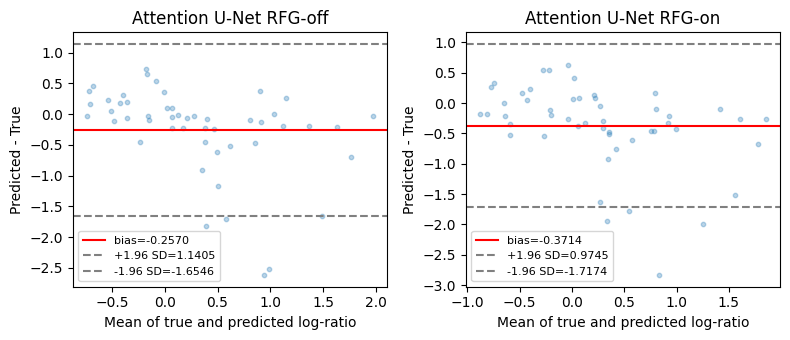

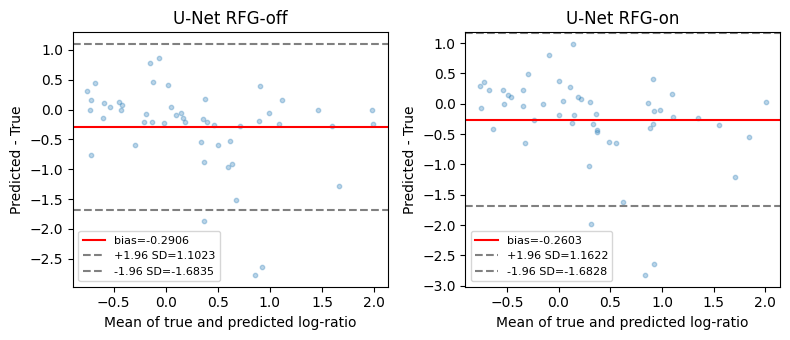

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
bland_altman_plot(attn_rfg_off_results["true_ratio"], attn_rfg_off_results["pred_ratio"], "Attention U-Net RFG-off", axes[0])
bland_altman_plot(attn_rfg_on_results["true_ratio"], attn_rfg_on_results["pred_ratio"], "Attention U-Net RFG-on", axes[1])
plt.tight_layout()
plt.savefig(os.path.join(GOLD_DIR, "bland_altman_attn_rfg_aml.png"), dpi=100, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
bland_altman_plot(unet_rfg_off_results["true_ratio"], unet_rfg_off_results["pred_ratio"], "U-Net RFG-off", axes[0])
bland_altman_plot(unet_rfg_on_results["true_ratio"], unet_rfg_on_results["pred_ratio"], "U-Net RFG-on", axes[1])
plt.tight_layout()
plt.savefig(os.path.join(GOLD_DIR, "bland_altman_unet_rfg_aml.png"), dpi=100, bbox_inches="tight")
plt.show()


 idx cls     dice     rerr
  31 MYO 0.631919 2.039089
   8 LYA 0.642098 2.499948
  29 MYO 0.649032 2.865834
  22 MON 0.685144 0.420828
  41 NGS 0.774981 0.219203
   1 BAS 0.783880 0.599481
  13 LYT 0.786481 1.242922
   6 KSC 0.795301 0.838253
  37 NGS 0.811454 0.064440
  11 LYT 0.816069 0.640563
  32 NGB 0.820942 0.917119
  14 LYT 0.838242 0.737842
   9 LYA 0.841993 0.889605
  19 MOB 0.845553 0.668927
   0 BAS 0.848853 0.617029
  42 NGS 0.848918 0.766832
   3 EBO 0.857857 0.820497
  16 MMZ 0.864349 0.641194
  33 NGB 0.865443 0.445301
   4 EOS 0.868320 0.403854
  18 MOB 0.874746 0.081778
  43 NGS 0.882346 0.063791
  28 MYO 0.884832 0.509952
   7 KSC 0.896361 0.064641
  17 MMZ 0.899970 0.497009
   5 EOS 0.900712 0.407188
  30 MYO 0.904781 0.432376
  40 NGS 0.907343 0.050730
  44 NGS 0.908493 0.027746
  38 NGS 0.910343 0.170056
  45 NGS 0.912748 0.477033
  24 MYB 0.918195 0.141393
  34 NGS 0.920632 0.237554
  25 MYB 0.931581 0.275026
  39 NGS 0.934111 0.376640
  48 PMO 0.939153 0.032077
 

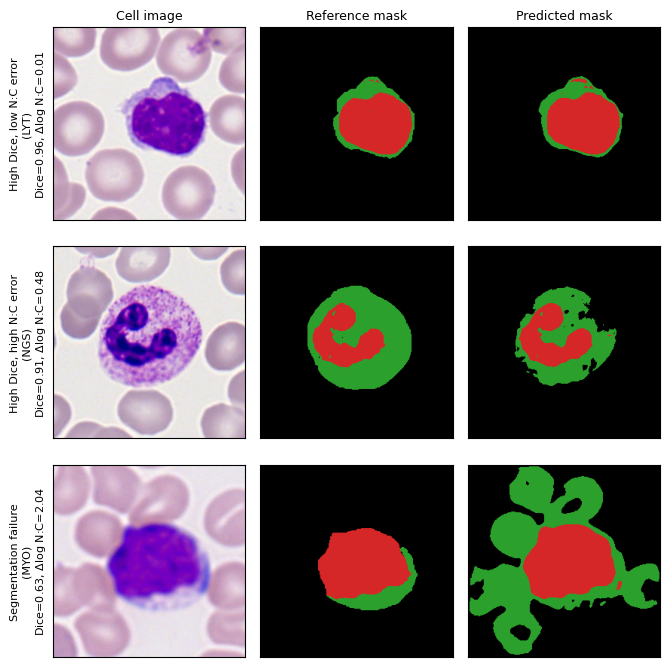

saved: /content/drive/MyDrive/AML_segmentation_project/figures/qualitative_cases.png


In [ ]:
import os, numpy as np, torch, pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

  # --- choose which trained model to visualise ---
CKPT = os.path.join(CHECKPOINT_DIR_AML, "aml_fullmethod_pretrained_seed2.pt")
USE_RFG = True

viz_model = SegModel("attention_unet", num_classes=3, use_rfg=USE_RFG).to(device)
viz_model.load_state_dict(torch.load(CKPT, map_location=device))
viz_model.eval()

MEAN, STD = np.array(AML_IMAGENET_MEAN), np.array(AML_IMAGENET_STD)
denorm = lambda t: np.clip(t.permute(1, 2, 0).cpu().numpy() * STD + MEAN, 0, 1)

def per_image_dice(pred, tgt, k=3):
    return float(np.mean([
        (2 * ((pred == c) & (tgt == c)).sum() + 1e-6) /
        ((pred == c).sum() + (tgt == c).sum() + 1e-6) for c in range(k)]))

recs = []
with torch.no_grad():
    for i in range(len(gold_dataset)):
      img_t, msk_t = gold_dataset[i]
      prob = F.softmax(viz_model(img_t.unsqueeze(0).to(device)), dim=1)[0]
      pred, tgt = prob.argmax(0).cpu().numpy(), msk_t.numpy()
      pred_lr = torch.log((prob[2].sum() + 1e-6) / (prob[1].sum() + 1e-6)).item()
      true_lr = np.log(((tgt == 2).sum() + 1e-6) / ((tgt == 1).sum() + 1e-6))
      recs.append(dict(idx=i, cls=gold_candidates_df.loc[i, "class"],
                          dice=per_image_dice(pred, tgt),
                          rerr=abs(pred_lr - true_lr),
                          img=denorm(img_t), pred=pred, tgt=tgt))

print(pd.DataFrame([{k: r[k] for k in ("idx", "cls", "dice", "rerr")}
                    for r in recs]).sort_values("dice").to_string(index=False))

d60 = np.percentile([r["dice"] for r in recs], 60)
good     = max(recs, key=lambda r: r["dice"] - 3 * r["rerr"])
mismatch = max([r for r in recs if r["dice"] >= d60], key=lambda r: r["rerr"])
fail     = min(recs, key=lambda r: r["dice"])
cases = [("High Dice, low N:C error", good),
          ("High Dice, high N:C error", mismatch),
          ("Segmentation failure", fail)]

cmap = ListedColormap(["black", "tab:green", "tab:red"])   # bg / cytoplasm / nucleus
fig, ax = plt.subplots(3, 3, figsize=(6.8, 6.9))
cols = ["Cell image", "Reference mask", "Predicted mask"]
for row, (label, r) in enumerate(cases):
    ax[row, 0].imshow(r["img"])
    ax[row, 1].imshow(r["tgt"], cmap=cmap, vmin=0, vmax=2)
    ax[row, 2].imshow(r["pred"], cmap=cmap, vmin=0, vmax=2)
    ax[row, 0].set_ylabel(f"{label}\n({r['cls']})\n"
                          f"Dice={r['dice']:.2f}, "
                          r"$\Delta$log N:C=" f"{r['rerr']:.2f}", fontsize=8)
    for c in range(3):
        ax[row, c].set_xticks([]); ax[row, c].set_yticks([])
        if row == 0:
            ax[row, c].set_title(cols[c], fontsize=9)

plt.tight_layout()
out = os.path.join(PROJECT_DIR, "figures", "qualitative_cases.png")
os.makedirs(os.path.dirname(out), exist_ok=True)
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print("saved:", out)